# PyTorch 선형회귀 모델
## 공부시간(x)에 따른 성적(y) 예측

이 노트북은 PyTorch를 사용하여 공부시간과 성적 간의 선형 관계를 학습하는 간단한 선형회귀 모델을 구현합니다.

## 1. 필요한 라이브러리 임포트

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# 한글 폰트 설정 (선택사항)
plt.rcParams['font.family'] = 'DejaVu Sans'
print("PyTorch 버전:", torch.__version__)

PyTorch 버전: 2.2.2+cu118


## 2. 샘플 데이터 생성

공부시간(x)과 성적(y)의 훈련 데이터를 생성합니다.

In [3]:
# 샘플 데이터: 공부시간(시간), 성적(점수)
x_data = np.array([[1.0], [2.0], [3.0], [4.0], [5.0], [6.0], [7.0], [8.0]], dtype=np.float32)
y_data = np.array([[2.0], [4.0], [5.0], [6.0], [8.0], [10.0], [11.0], [13.0]], dtype=np.float32)

# NumPy 배열을 PyTorch 텐서로 변환
x_train = torch.from_numpy(x_data)
y_train = torch.from_numpy(y_data)

print("학습 데이터 (공부시간):")
print(x_train)
print("\n학습 데이터 (성적):")
print(y_train)
print(f"\n데이터 형태: x={x_train.shape}, y={y_train.shape}")

학습 데이터 (공부시간):
tensor([[1.],
        [2.],
        [3.],
        [4.],
        [5.],
        [6.],
        [7.],
        [8.]])

학습 데이터 (성적):
tensor([[ 2.],
        [ 4.],
        [ 5.],
        [ 6.],
        [ 8.],
        [10.],
        [11.],
        [13.]])

데이터 형태: x=torch.Size([8, 1]), y=torch.Size([8, 1])
tensor([[1.],
        [2.],
        [3.],
        [4.],
        [5.],
        [6.],
        [7.],
        [8.]])

학습 데이터 (성적):
tensor([[ 2.],
        [ 4.],
        [ 5.],
        [ 6.],
        [ 8.],
        [10.],
        [11.],
        [13.]])

데이터 형태: x=torch.Size([8, 1]), y=torch.Size([8, 1])


## 3. 선형회귀 모델 생성

입력값 1개를 받아 출력값 1개를 생성하는 간단한 선형 모델을 정의합니다.

In [4]:
# 선형회귀 모델 정의
# y = wx + b (w: 가중치, b: 편향)
model = nn.Linear(1, 1)

# 모델 정보 출력
print("모델 구조:")
print(model)
print("\n초기 가중치 (w):", model.weight.data)
print("초기 편향 (b):", model.bias.data)

모델 구조:
Linear(in_features=1, out_features=1, bias=True)

초기 가중치 (w): tensor([[-0.6097]])
초기 편향 (b): tensor([-0.5668])


## 4. 손실함수와 옵티마이저 정의

MSE(평균 제곱 오차) 손실함수와 SGD 옵티마이저를 사용합니다.

In [5]:
# 손실함수 정의 (MSE: Mean Squared Error)
criterion = nn.MSELoss()

# 옵티마이저 정의 (SGD: Stochastic Gradient Descent)
# learning_rate는 학습 속도를 조절하는 하이퍼파라미터
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

print("손실함수: Mean Squared Error (MSE)")
print("옵티마이저: SGD (learning_rate=0.01)")

손실함수: Mean Squared Error (MSE)
옵티마이저: SGD (learning_rate=0.01)


## 5. 모델 훈련

여러 epoch 동안 모델을 훈련합니다.

In [6]:
# 훈련 파라미터
epochs = 100
losses = []

# 훈련 루프
print("훈련 시작...\n")
for epoch in range(epochs):
    # Forward pass: 모델 예측
    y_pred = model(x_train)
    
    # Loss 계산
    loss = criterion(y_pred, y_train)
    losses.append(loss.item())
    
    # Backward pass: 그래디언트 계산
    optimizer.zero_grad()  # 이전 그래디언트 초기화
    loss.backward()        # 역전파
    
    # Parameter 업데이트
    optimizer.step()
    
    # 10 epoch마다 결과 출력
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

print("\n훈련 완료!")
print(f"\n최종 가중치 (w): {model.weight.data.item():.4f}")
print(f"최종 편향 (b): {model.bias.data.item():.4f}")

훈련 시작...

Epoch [10/100], Loss: 0.1788
Epoch [20/100], Loss: 0.1728
Epoch [30/100], Loss: 0.1674
Epoch [40/100], Loss: 0.1624
Epoch [50/100], Loss: 0.1578
Epoch [60/100], Loss: 0.1536
Epoch [70/100], Loss: 0.1497
Epoch [80/100], Loss: 0.1461
Epoch [90/100], Loss: 0.1427
Epoch [100/100], Loss: 0.1396

훈련 완료!

최종 가중치 (w): 1.6108
최종 편향 (b): 0.0423
Epoch [10/100], Loss: 0.1788
Epoch [20/100], Loss: 0.1728
Epoch [30/100], Loss: 0.1674
Epoch [40/100], Loss: 0.1624
Epoch [50/100], Loss: 0.1578
Epoch [60/100], Loss: 0.1536
Epoch [70/100], Loss: 0.1497
Epoch [80/100], Loss: 0.1461
Epoch [90/100], Loss: 0.1427
Epoch [100/100], Loss: 0.1396

훈련 완료!

최종 가중치 (w): 1.6108
최종 편향 (b): 0.0423


## 6. 새로운 데이터로 예측

훈련된 모델을 사용하여 새로운 공부시간에 대한 성적을 예측합니다.

In [7]:
# 새로운 데이터로 예측
x_test = torch.tensor([[9.5]], dtype=torch.float32)

# 모델을 평가 모드로 설정 (드롭아웃 비활성화 등)
model.eval()
with torch.no_grad():
    y_pred = model(x_test)

print(f"공부시간: 9.5시간")
print(f"예측 성적: {y_pred.item():.2f}점")

# 여러 값으로 예측
print("\n여러 공부시간에 대한 예측:")
test_hours = torch.tensor([[3.5], [5.5], [7.5], [10.0]], dtype=torch.float32)
with torch.no_grad():
    predictions = model(test_hours)

for hour, pred in zip(test_hours.numpy(), predictions.numpy()):
    print(f"공부시간: {hour[0]:.1f}시간 -> 예측 성적: {pred[0]:.2f}점")

공부시간: 9.5시간
예측 성적: 15.34점

여러 공부시간에 대한 예측:
공부시간: 3.5시간 -> 예측 성적: 5.68점
공부시간: 5.5시간 -> 예측 성적: 8.90점
공부시간: 7.5시간 -> 예측 성적: 12.12점
공부시간: 10.0시간 -> 예측 성적: 16.15점


## 7. 결과 시각화

훈련 데이터와 회귀선을 함께 그려서 모델의 성능을 시각화합니다.

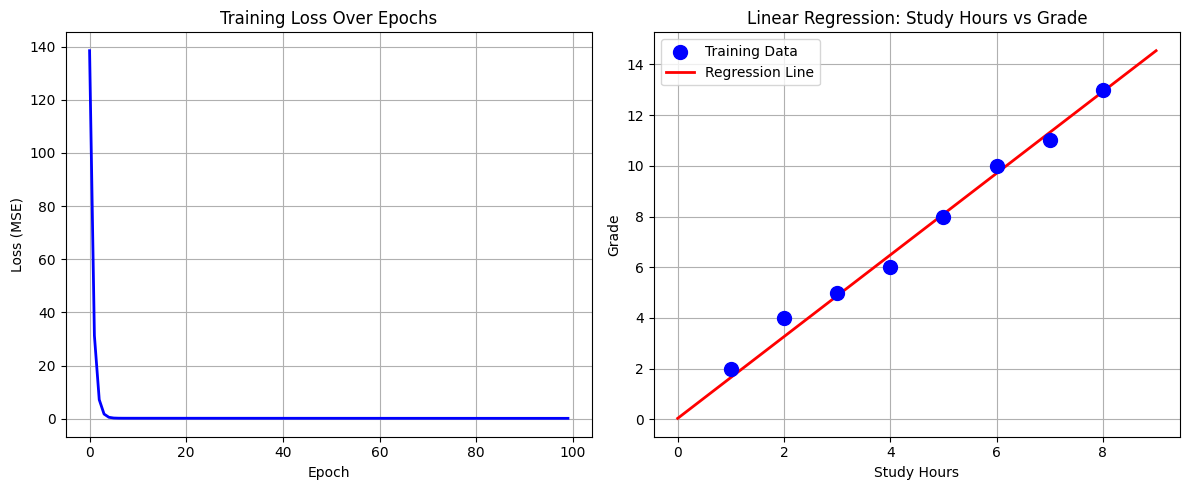

시각화 완료!


In [8]:
# 손실 함수 변화 시각화
plt.figure(figsize=(12, 5))

# 첫 번째 그래프: Loss 감소 추이
plt.subplot(1, 2, 1)
plt.plot(losses, 'b-', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss Over Epochs')
plt.grid(True)

# 두 번째 그래프: 회귀선과 데이터점
plt.subplot(1, 2, 2)
x_np = x_train.numpy()
y_np = y_train.numpy()

# 훈련 데이터점 표시
plt.scatter(x_np, y_np, color='blue', s=100, label='Training Data', zorder=5)

# 회귀선 그리기
x_line = np.linspace(0, 9, 100).reshape(-1, 1)
x_line_tensor = torch.from_numpy(x_line.astype(np.float32))
with torch.no_grad():
    y_line = model(x_line_tensor).numpy()

plt.plot(x_line, y_line, 'r-', linewidth=2, label='Regression Line')
plt.xlabel('Study Hours')
plt.ylabel('Grade')
plt.title('Linear Regression: Study Hours vs Grade')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("시각화 완료!")